<a href="https://colab.research.google.com/github/mayankagg2001/Anomaly-Detection/blob/main/Anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install kaggle

### 1. Get your Kaggle API Token

*   Go to Kaggle: [https://www.kaggle.com/](https://www.kaggle.com/)
*   Log in to your account.
*   Click on your profile picture in the top right corner and select "My Account".
*   Scroll down to the "API" section and click "Create New API Token". This will download a `kaggle.json` file to your computer. Open this file with a text editor to get your `username` and `key`.

### 2. Store your Kaggle Credentials as Colab Secrets

To securely store your credentials:

*   On the left sidebar of Colab, click the "🔑 Secrets" icon.
*   Add two new secrets:
    *   **Name:** `KAGGLE_USERNAME`, **Value:** Your Kaggle username (e.g., `your_username`)
    *   **Name:** `KAGGLE_KEY`, **Value:** Your Kaggle API key (e.g., `XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX`)

Make sure the 'Notebook access' toggle is enabled for both secrets.

In [ ]:
import os
from google.colab import userdata

# Load Kaggle credentials from Colab secrets
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded from Colab secrets.")

Kaggle credentials loaded from Colab secrets.


### 3. Test your Kaggle API Connection

Now that your credentials are set, you can test the Kaggle API connection by listing competitions:

In [ ]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [ ]:
import kagglehub
# Download the credit card fraud dataset from Kaggle
path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
print(f'Dataset downloaded to: {path}')

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset downloaded to: /kaggle/input/creditcardfraud


In [ ]:
path

'/kaggle/input/creditcardfraud'

In [ ]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'creditcard.csv')

# Load the dataset
df = pd.read_csv(csv_file_path)

# Preview the data
print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
anomaly_df = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0]

In [ ]:
print(anomaly_df.shape)
print(normal_df.shape)

(492, 31)
(284315, 31)


In [ ]:
import matplotlib.pyplot as plt

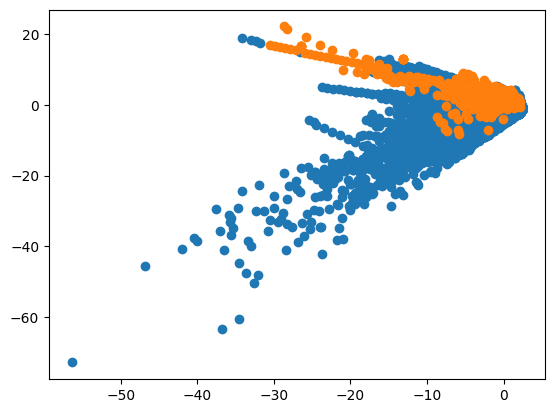

In [ ]:
plt.scatter(normal_df['V1'], normal_df['V2'])
plt.scatter(anomaly_df['V1'], anomaly_df['V2'])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Scale 'Amount' and 'Time' features
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# Split the data into training and testing sets (optional for unsupervised, but good for evaluation setup)
# We will use the entire dataset for training the Isolation Forest as it's unsupervised

# Train Isolation Forest model
# Contamination is an important parameter: proportion of outliers in the data set
# Since we know the approximate proportion of anomalies (492 out of 284807), we can use that.
# 492 / 284807 = 0.001727
contamination_rate = anomaly_df.shape[0] / df.shape[0]
print(f"Contamination Rate (approximate anomaly proportion): {contamination_rate:.4f}")

isolation_forest = IsolationForest(contamination=contamination_rate, random_state=42)
isolation_forest.fit(X)

# Predict anomalies (-1 for outliers, 1 for inliers)
predictions = isolation_forest.predict(X)

# Convert predictions to 0 (normal) and 1 (anomaly) to match 'Class' column
predictions[predictions == 1] = 0  # Inliers are normal
predictions[predictions == -1] = 1 # Outliers are anomalies

print("Isolation Forest Model Trained and Predictions Made!")


Contamination Rate (approximate anomaly proportion): 0.0017
Isolation Forest Model Trained and Predictions Made!


Now, let's evaluate the performance of our anomaly detection model.

In [ ]:
print("Classification Report:")
print(classification_report(y, predictions))

print(f"Accuracy Score: {accuracy_score(y, predictions):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.26      0.26      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807

Accuracy Score: 0.9974


In [ ]:
from scipy.stats import norm

# Separate features (X) and target (y) again, using the scaled X
# X and y are already prepared from the previous Isolation Forest step
# X = df.drop('Class', axis=1)
# y = df['Class']

# Step 1: Estimate parameters (mean and standard deviation) from normal data
X_normal = X[y == 0]

mu = X_normal.mean()
sigma = X_normal.std()

print("Calculated mean and standard deviation for normal transactions.")

# Step 2: Calculate the probability density for each transaction
# We will use the log probability to avoid underflow issues with very small numbers
def calculate_log_probabilities(data, mu, sigma):
    log_probs = pd.DataFrame(index=data.index)
    for col in data.columns:
        log_probs[col] = norm.logpdf(data[col], loc=mu[col], scale=sigma[col])

    # Sum the log probabilities across features for each sample
    # Assuming independence, P(x1, x2, ...) = P(x1) * P(x2) * ...
    # So, log(P(x1, x2, ...)) = log(P(x1)) + log(P(x2)) + ...
    return log_probs.sum(axis=1)

combined_log_probabilities = calculate_log_probabilities(X, mu, sigma)

print("Calculated combined log probabilities for all transactions.")

Calculated mean and standard deviation for normal transactions.
Calculated combined log probabilities for all transactions.


Now, we need to set a threshold to classify transactions as normal or anomalous. A common approach is to find a threshold that captures a certain percentile of the *normal* data's probabilities. Since anomalies should have very low probabilities, we'll look for a low percentile.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Calculate log probabilities for only the normal class to determine a threshold
normal_log_probabilities = calculate_log_probabilities(X_normal, mu, sigma)

# Determine a threshold. We want to find a value below which we consider a transaction anomalous.
# Let's try to set a threshold based on the `contamination_rate` or a small percentile.
# For example, we can use the value at the `contamination_rate` percentile of the normal log probabilities.
threshold = normal_log_probabilities.quantile(contamination_rate)

print(f"Calculated threshold: {threshold:.4f}")

# Classify predictions based on the threshold
gaussian_predictions = (combined_log_probabilities < threshold).astype(int)

# Evaluate the results
print("\nGaussian Probability Method Classification Report:")
print(classification_report(y, gaussian_predictions))

print(f"Accuracy Score: {accuracy_score(y, gaussian_predictions):.4f}")

Calculated threshold: -392.8222

Gaussian Probability Method Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.23      0.29      0.26       492

    accuracy                           1.00    284807
   macro avg       0.61      0.65      0.63    284807
weighted avg       1.00      1.00      1.00    284807

Accuracy Score: 0.9971


Compare these results with the Isolation Forest. The effectiveness of the Gaussian probability method largely depends on how well the features follow a Gaussian distribution and the assumption of independence. If the features are not truly independent or Gaussian, the performance might be limited.

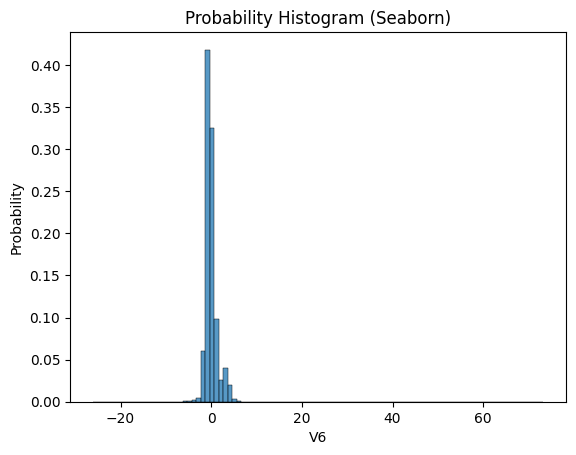

In [ ]:
import seaborn as sns

sns.histplot(X['V6'], stat="probability", bins=100)
plt.title("Probability Histogram (Seaborn)")
plt.show()

# Task
Calculate the absolute correlation of each feature in the `df` DataFrame with the 'Class' column, and then select the top 10 features that are most correlated with 'Class'.

## Select Top 10 Features

### Subtask:
Calculate the absolute correlation of each feature with the 'Class' column (target variable) and select the top 10 most correlated features. This will help in identifying the most relevant features for distinguishing anomalies.


**Reasoning**:
To identify the most relevant features for anomaly detection, I will calculate the absolute correlation of each feature with the 'Class' column in the `df` DataFrame, sort them, and then select the top 10 features.



In [ ]:
import pandas as pd

# Define the number of top features to select
num_features_to_select = 5 # You can change this value to experiment with different numbers of features

# Calculate the correlation of all features with the 'Class' column
correlations = df.corr()['Class']

# Take the absolute value of these correlations
absolute_correlations = correlations.abs()

# Sort the absolute correlations in descending order
sorted_correlations = absolute_correlations.sort_values(ascending=False)

# Select the top N feature names, excluding 'Class' itself
top_10_features = sorted_correlations[1:num_features_to_select+1].index.tolist()

print(f"Top {num_features_to_select} most correlated features with 'Class':")
print(top_10_features)


Top 5 most correlated features with 'Class':
['V17', 'V14', 'V12', 'V10', 'V16']


## Normalize Selected Features

### Subtask:
Apply StandardScaler to the selected top 10 features to normalize their values. This ensures that all features contribute equally to the model without being dominated by features with larger scales.


**Reasoning**:
I will create a new DataFrame `X_selected` containing only the top 10 features, then apply `StandardScaler` to normalize these features, and finally display the head of the scaled DataFrame to verify the normalization.



In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create a new DataFrame X_selected with only the top 10 features
X_selected = X[top_10_features].copy()

# Initialize a StandardScaler object
scaler_selected = StandardScaler()

# Fit the scaler to X_selected and then transform X_selected
X_selected_scaled = pd.DataFrame(scaler_selected.fit_transform(X_selected), columns=X_selected.columns, index=X_selected.index)

print("First 5 rows of the scaled X_selected DataFrame:")
display(X_selected_scaled.head())

First 5 rows of the scaled X_selected DataFrame:


,V17,V14,V12,V10,V16
0,0.244863,-0.324610,-0.618296,0.083386,-0.536833
1,-0.135170,-0.149982,1.066089,-0.153350,0.529434
2,1.306868,-0.173114,0.066137,0.190700,-3.298235
3,-0.805445,-0.300360,0.178371,-0.050468,-1.209296
4,-0.279081,-1.168034,0.538627,0.691625,-0.515205


## Estimate Gaussian Parameters

### Subtask:
Estimate the mean and standard deviation for each of the normalized, selected features, using only the normal transactions (where 'Class' is 0). These parameters will define the Gaussian distribution for normal data.


**Reasoning**:
To estimate the Gaussian parameters (mean and standard deviation) for only the normal transactions, I need to first filter the `X_selected_scaled` DataFrame using the `y` Series to isolate normal transactions. Then, I will calculate the mean and standard deviation for each column of this filtered dataset.



In [ ]:
import pandas as pd

# 1. Filter X_selected_scaled to include only normal transactions (where 'Class' is 0)
# Ensure that the index of y aligns with X_selected_scaled
X_normal_selected_scaled = X_selected_scaled[y == 0]

# 2. Calculate the mean for each column
mu_selected = X_normal_selected_scaled.mean()

# 3. Calculate the standard deviation for each column
sigma_selected = X_normal_selected_scaled.std()

# 4. Print a confirmation message
print("Mean and standard deviation calculated for selected normal transactions:")
print("Mean (mu_selected):")
print(mu_selected)
print("\nStandard Deviation (sigma_selected):")
print(sigma_selected)

Mean and standard deviation calculated for selected normal transactions:
Mean (mu_selected):
V17    0.013581
V14    0.012586
V12    0.010840
V10    0.009022
V16    0.008176
dtype: float64

Standard Deviation (sigma_selected):
V17    0.882403
V14    0.935752
V12    0.946697
V10    0.958999
V16    0.964075
dtype: float64


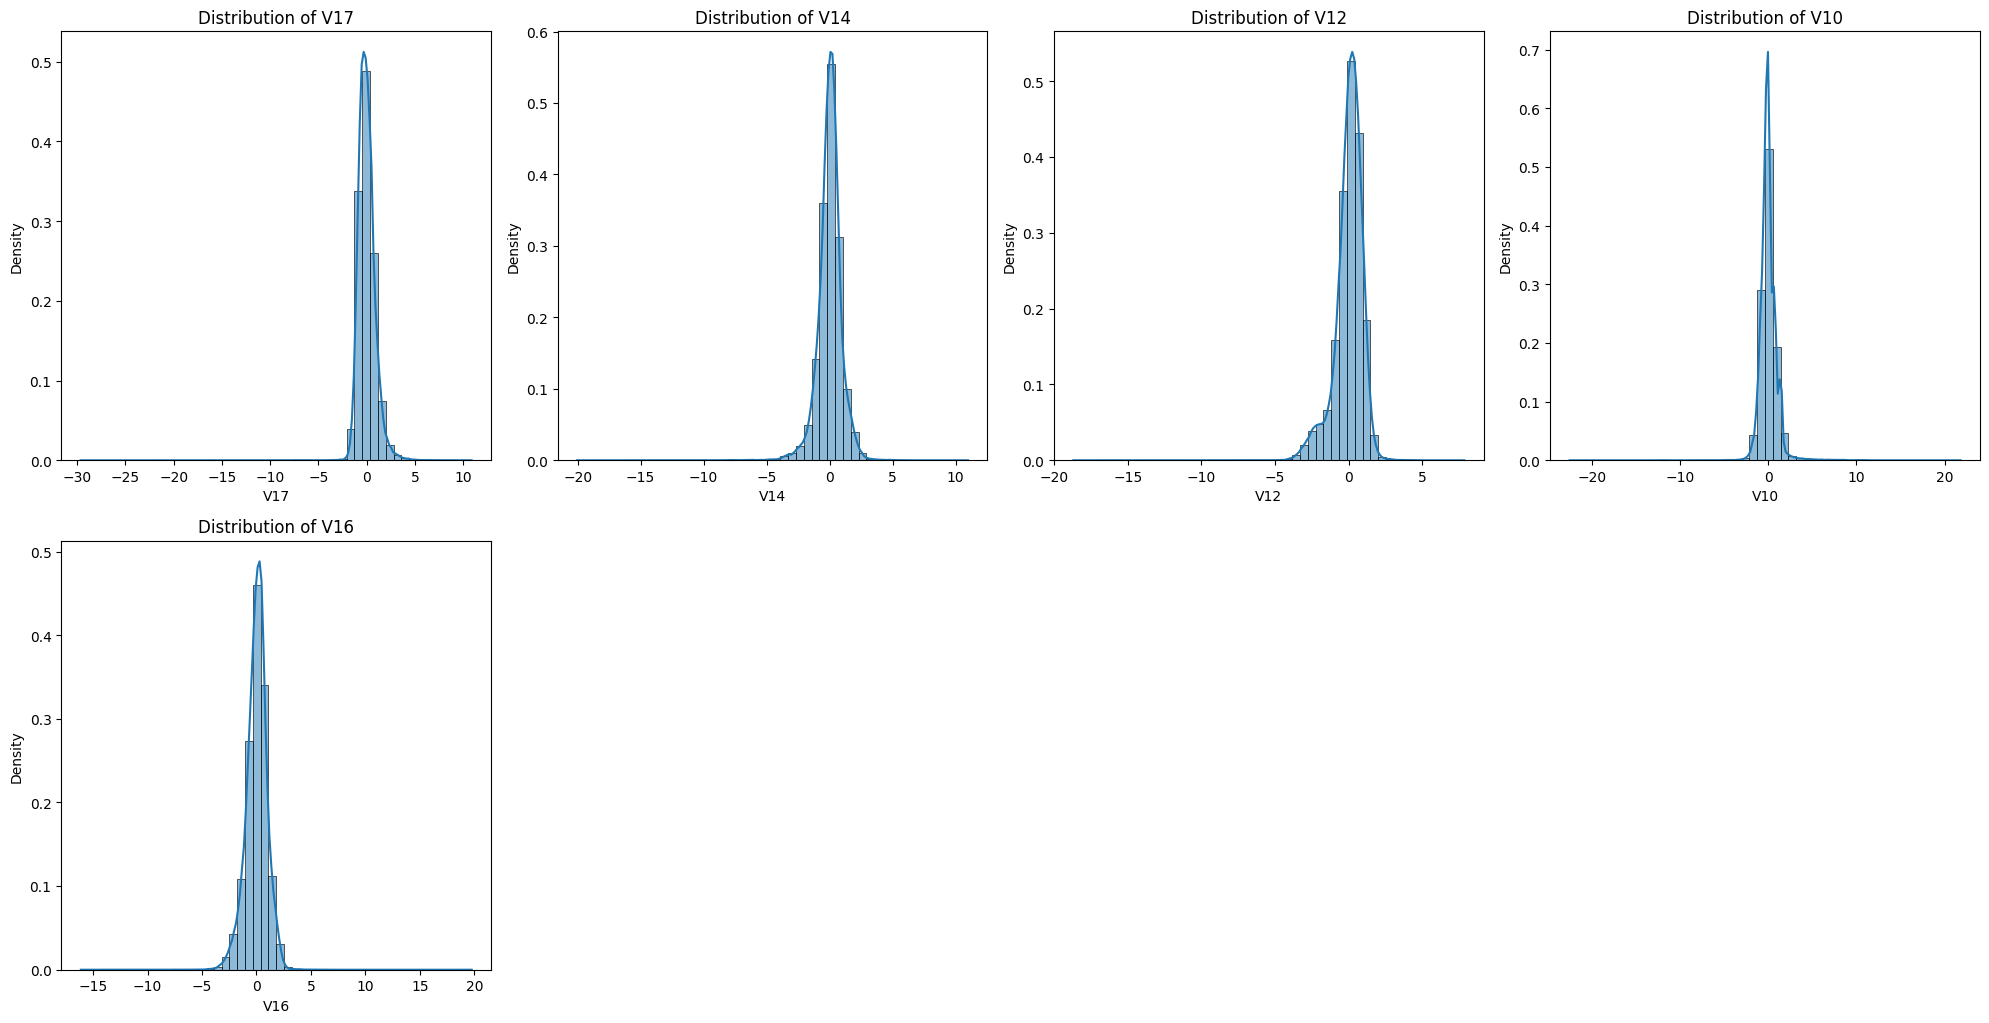

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_selected_scaled and top_10_features are already defined in the notebook

plt.figure(figsize=(20, 15))
for i, feature in enumerate(top_10_features):
    plt.subplot(3, 4, i + 1)  # Adjust subplot grid as needed, e.g., 3 rows, 4 columns for 10 features
    sns.histplot(X_selected_scaled[feature], stat="density", kde=True, bins=50)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()


## Calculate Log Probabilities

### Subtask:
Calculate the combined log probabilities for all transactions (both normal and anomalous) based on the estimated Gaussian parameters of the normal data and using only the normalized, selected features. Transactions with lower log probabilities are more likely to be anomalies.


**Reasoning**:
To calculate the combined log probabilities for all transactions using the selected and scaled features, I will reuse the `calculate_log_probabilities` function with `X_selected_scaled`, `mu_selected`, and `sigma_selected`.



In [ ]:
from scipy.stats import norm
import pandas as pd

# Reuse the calculate_log_probabilities function
def calculate_log_probabilities(data, mu, sigma):
    log_probs = pd.DataFrame(index=data.index)
    for col in data.columns:
        # Ensure standard deviation is not zero to avoid division by zero errors
        # Replace 0 with a very small number if it occurs
        current_sigma = sigma[col] if sigma[col] != 0 else 1e-9
        log_probs[col] = norm.logpdf(data[col], loc=mu[col], scale=current_sigma)
    return log_probs.sum(axis=1)

# Apply the function to X_selected_scaled using mu_selected and sigma_selected
combined_log_probabilities_selected = calculate_log_probabilities(X_selected_scaled, mu_selected, sigma_selected)

print("Combined log probabilities for selected features calculated.")


Combined log probabilities for selected features calculated.


## Classify Transactions and Evaluate Performance

### Subtask:
Set a threshold for the combined log probabilities to classify transactions as normal or anomalous, and then evaluate the performance of this anomaly detection method using appropriate metrics like `classification_report` and `accuracy_score`.

### Reasoning:
To classify transactions, I will first calculate the log probabilities for normal transactions based on the selected features and their Gaussian parameters. Then, I will determine a threshold using the `contamination_rate` to separate normal from anomalous transactions. Finally, I will classify all transactions based on this threshold and evaluate the model's performance against the true 'Class' labels.

**Reasoning**:
To classify transactions as normal or anomalous, I need to first calculate the log probabilities for normal transactions using the selected and scaled features. Then, I will determine a threshold based on the `contamination_rate` from these normal log probabilities. Finally, I will apply this threshold to the combined log probabilities of all transactions to make predictions and evaluate the model's performance.



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Calculate log probabilities for only the normal class using selected and scaled features
# X_normal_selected_scaled was already created in a previous step
normal_log_probabilities_selected = calculate_log_probabilities(X_normal_selected_scaled, mu_selected, sigma_selected)

# Determine a threshold. We want to find a value below which we consider a transaction anomalous.
# We will use the value at the `contamination_rate` percentile of the normal log probabilities.
threshold_selected = normal_log_probabilities_selected.quantile(contamination_rate)

print(f"Calculated threshold for selected features: {threshold_selected:.4f}")

# Classify predictions based on the threshold
gaus_predictions_selected = (combined_log_probabilities_selected < threshold_selected).astype(int)

# Evaluate the results
print("\nGaussian Probability Method (Selected Features) Classification Report:")
print(classification_report(y, gaus_predictions_selected))

print(f"Accuracy Score: {accuracy_score(y, gaus_predictions_selected):.4f}")

Calculated threshold for selected features: -48.7121

Gaussian Probability Method (Selected Features) Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.43      0.76      0.55       492

    accuracy                           1.00    284807
   macro avg       0.72      0.88      0.78    284807
weighted avg       1.00      1.00      1.00    284807

Accuracy Score: 0.9979


### Comparison of Gaussian Probability with Different Feature Counts

We will now automate the process of selecting the top $N$ features (where $N$ ranges from 6 to 10), training the Gaussian model, and collecting performance metrics to find the optimal configuration.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Ensure sorted_correlations is defined by recalculating it
correlations = df.corr()['Class']
absolute_correlations = correlations.abs()
sorted_correlations = absolute_correlations.sort_values(ascending=False)

results = []

# Iterate from 5 to 10 features to see the performance change
for n in range(5, 11):
    # 1. Select top N features (excluding 'Class' itself at index 0)
    current_features = sorted_correlations[1:n+1].index.tolist()

    # 2. Scale these features
    X_temp = X[current_features].copy()
    scaler_temp = StandardScaler()
    X_scaled_temp = pd.DataFrame(scaler_temp.fit_transform(X_temp), columns=X_temp.columns, index=X_temp.index)

    # 3. Estimate parameters from normal data
    X_norm_temp = X_scaled_temp[y == 0]
    mu_temp = X_norm_temp.mean()
    sigma_temp = X_norm_temp.std()

    # 4. Calculate log probabilities using the helper function defined earlier
    log_probs_all = calculate_log_probabilities(X_scaled_temp, mu_temp, sigma_temp)
    log_probs_norm = calculate_log_probabilities(X_norm_temp, mu_temp, sigma_temp)

    # 5. Set threshold based on contamination rate and predict
    thresh_temp = log_probs_norm.quantile(contamination_rate)
    preds_temp = (log_probs_all < thresh_temp).astype(int)

    # 6. Store metrics for comparison
    results.append({
        'Num Features': n,
        'Features': ', '.join(current_features),
        'Precision': precision_score(y, preds_temp),
        'Recall': recall_score(y, preds_temp),
        'F1-Score': f1_score(y, preds_temp),
        'Accuracy': accuracy_score(y, preds_temp)
    })

# Create and display the comparison table
comparison_df = pd.DataFrame(results)
display(comparison_df)

,Num Features,Features,Precision,Recall,F1-Score,Accuracy
0,5,"V17, V14, V12, V10, V16",0.432526,0.762195,0.551876,0.997862
1,6,"V17, V14, V12, V10, V16, V3",0.412888,0.703252,0.520301,0.997760
2,7,"V17, V14, V12, V10, V16, V3, V7",0.381910,0.617886,0.472050,0.997612
3,8,"V17, V14, V12, V10, V16, V3, V7, V11",0.382685,0.619919,0.473235,0.997616
4,9,"V17, V14, V12, V10, V16, V3, V7, V11, V4",0.383459,0.621951,0.474419,0.997619
5,10,"V17, V14, V12, V10, V16, V3, V7, V11, V4, V18",0.382685,0.619919,0.473235,0.997616


## Final Task

### Subtask:
Summarize the results of the anomaly detection model after feature selection and normalization, comparing its performance to previous iterations if applicable.


### Improving Model Performance with Supervised Learning (XGBoost)

Unsupervised methods like Isolation Forest and Gaussian Probability are great for finding 'weird' data, but since we have labels, we can train a classifier specifically to recognize fraud. We will use **XGBoost** with a `scale_pos_weight` parameter to handle the fact that fraud is very rare.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:36:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Supervised Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.87      0.47        98

    accuracy                           1.00     56962
   macro avg       0.66      0.93      0.74     56962
weighted avg       1.00      1.00      1.00     56962



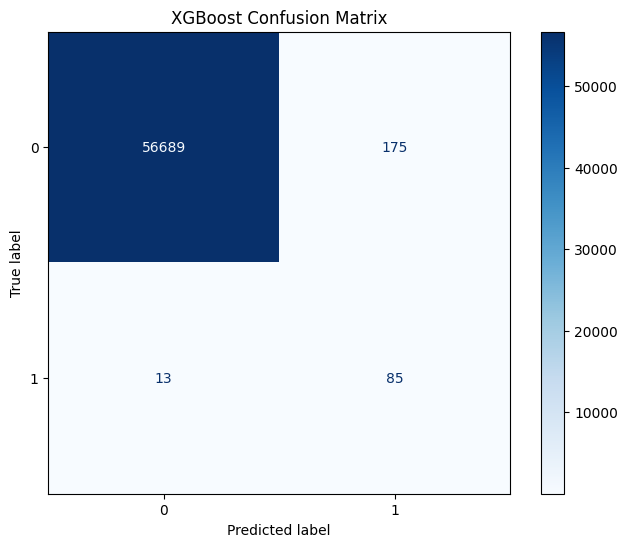

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the ratio for scale_pos_weight: (count of negative / count of positive)
ratio = float(y[y == 0].count()) / y[y == 1].count()

# Initialize XGBoost with class weighting
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Split data for a proper supervised evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = xgb_model.predict(X_test)

print("XGBoost Supervised Model Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

### Handling Class Imbalance with SMOTE

Instead of just weighting the classes, we can use **SMOTE** to create synthetic examples of the minority class. This often helps the model generalize better for the rare class.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE to the training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training dataset shape: {Counter(y_train)}")
print(f"Resampled training dataset shape: {Counter(y_train_res)}")

Original training dataset shape: Counter({0: 227451, 1: 394})
Resampled training dataset shape: Counter({0: 227451, 1: 227451})


Now we train the XGBoost model on the balanced dataset produced by SMOTE.

XGBoost + SMOTE Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.89      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962



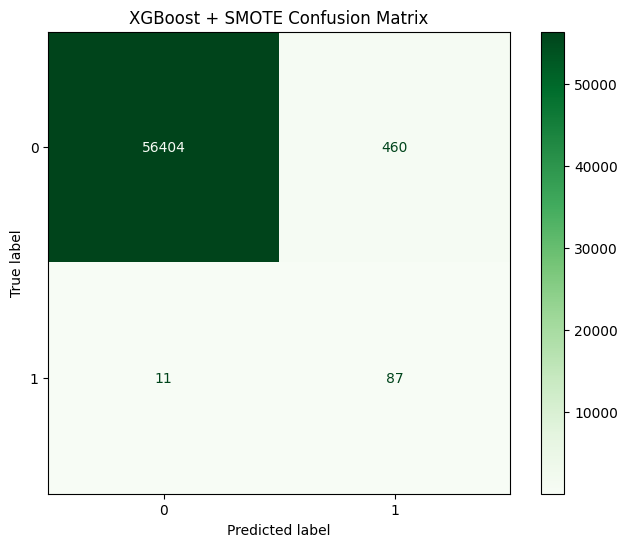

In [ ]:
# Initialize XGBoost (we don't need scale_pos_weight since the data is now balanced)
xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Train on the resampled data
xgb_smote.fit(X_train_res, y_train_res)

# Predict on the original (unseen) test set
y_pred_smote = xgb_smote.predict(X_test)

print("XGBoost + SMOTE Classification Report:")
print(classification_report(y_test, y_pred_smote))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, ax=ax, cmap='Greens')
plt.title('XGBoost + SMOTE Confusion Matrix')
plt.show()

### Hybrid Approach: SMOTE + Isolation Forest

Here we use SMOTE to oversample the minority class and then train an Isolation Forest on the resampled data. Note that we must determine a new contamination rate based on the balanced dataset.

Isolation Forest + SMOTE Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.11      0.02      0.03        98

    accuracy                           1.00     56962
   macro avg       0.55      0.51      0.52     56962
weighted avg       1.00      1.00      1.00     56962



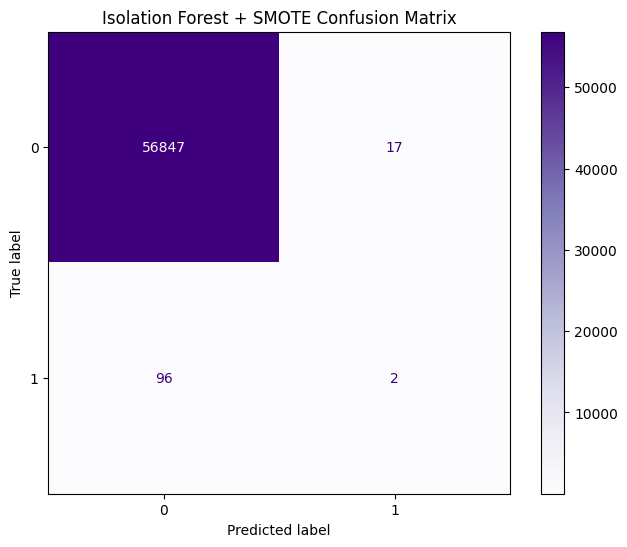

In [ ]:
from sklearn.ensemble import IsolationForest

# On the resampled data (X_train_res), the classes are 50/50.
# However, we still want to detect anomalies in a way that aligns with the original test set.
# We will fit the model on the resampled training data.

# Since it's balanced 50/50 now, the 'contamination' concept changes.
# Let's try training it and predicting on the test set.
iso_forest_smote = IsolationForest(contamination=0.01, random_state=42)
iso_forest_smote.fit(X_train_res)

# Predict on test set
# Isolation Forest outputs -1 for outliers and 1 for inliers
test_preds_raw = iso_forest_smote.predict(X_test)

# Map to 0 (normal) and 1 (fraud)
test_preds_iso_smote = np.where(test_preds_raw == 1, 0, 1)

print("Isolation Forest + SMOTE Classification Report:")
print(classification_report(y_test, test_preds_iso_smote))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds_iso_smote, ax=ax, cmap='Purples')
plt.title('Isolation Forest + SMOTE Confusion Matrix')
plt.show()

```markdown
### Supervised Learning: Random Forest + SMOTE

Random Forest is an ensemble of decision trees that can be very effective at capturing non-linear relationships. We will train it on the `X_train_res` and `y_train_res` datasets produced by SMOTE.
```

Random Forest + SMOTE Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.88      0.58        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962



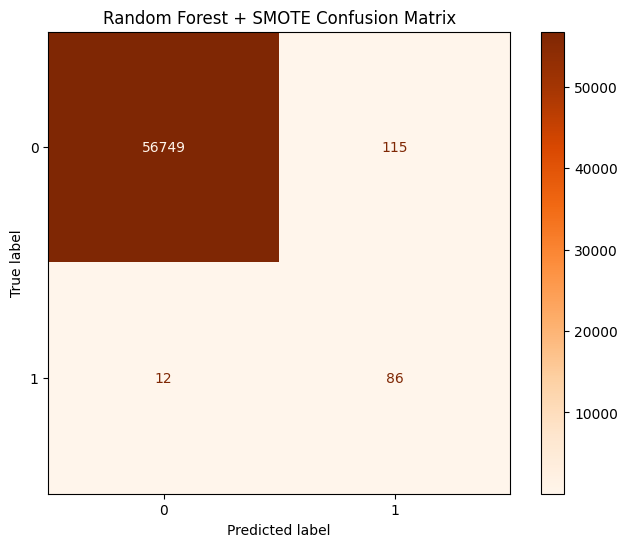

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10, # Limiting depth to prevent overfitting on synthetic samples
    random_state=42,
    n_jobs=-1
)

# Train on the resampled data
rf_smote.fit(X_train_res, y_train_res)

# Predict on the test set
y_pred_rf = rf_smote.predict(X_test)

print("Random Forest + SMOTE Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, cmap='Oranges')
plt.title('Random Forest + SMOTE Confusion Matrix')
plt.show()


### Hyperparameter Tuning with GridSearchCV

We will now use a grid search to find the optimal parameters for our Random Forest. This process evaluates multiple combinations of settings to find the one that produces the best F1-score.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define a parameter grid to search
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],
    'min_samples_leaf': [1, 2]
}

# Initialize the Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1
)

# Fit the grid search to the resampled training data
# Note: This might take a few minutes due to the size of the SMOTE dataset
grid_search.fit(X_train_res, y_train_res)

# Get the best model
best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the best model on the test set
y_pred_best = best_rf.predict(X_test)
print("\nOptimized Random Forest Classification Report:")
print(classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 100}

Optimized Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.66      0.85      0.74        98

    accuracy                           1.00     56962
   macro avg       0.83      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962



### Tuning SMOTE Sampling Strategy

By default, SMOTE balances the classes 50/50. However, sometimes a more moderate oversampling (e.g., making the minority class 10% or 25% of the size of the majority) leads to better generalization. We will use a Pipeline to ensure SMOTE is only applied to the training folds during cross-validation, preventing data leakage.

In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the pipeline: SMOTE then Random Forest
# We use the best RF parameters found in the previous step
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=2, n_jobs=-1, random_state=42))
])

# Define the parameter grid for SMOTE sampling_strategy
# 0.1 means the minority class will be 10% of the majority class size
param_grid = {
    'smote__sampling_strategy': [0.1, 0.25, 0.5, 1.0]
}

grid_search_smote = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1',
    cv=3,
    verbose=1
)

print("Searching for optimal SMOTE sampling ratio...")
grid_search_smote.fit(X_train, y_train)

print(f"Best SMOTE Strategy: {grid_search_smote.best_params_['smote__sampling_strategy']}")

# Evaluate on test set
y_pred_tuned_smote = grid_search_smote.predict(X_test)
print("\nClassification Report with Tuned SMOTE Ratio:")
print(classification_report(y_test, y_pred_tuned_smote))

Searching for optimal SMOTE sampling ratio...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best SMOTE Strategy: 0.1

Classification Report with Tuned SMOTE Ratio:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### Strategies for Further Improvement

To push the model performance beyond the current 86% F1-score, we can consider the following advanced techniques:

1. **Feature Engineering**:
   - **Interaction Terms**: Creating features like `V17 * V14` or `V12 / Amount` to capture non-linear relationships.
   - **Time Analysis**: Since 'Time' is seconds from the first transaction, we could derive 'Hour of Day' to see if fraud is more prevalent at night.

2. **Threshold Optimization**:
   - Currently, we use the default `0.5` probability threshold. By plotting a **Precision-Recall Curve**, we can choose a custom threshold that prioritizes Recall (catching every fraud) or Precision (minimizing false alarms) depending on business needs.

3. **Cost-Sensitive Learning**:
   - We can pass a `sample_weight` to the Random Forest, assigning a much higher 'cost' to missing a fraud case (False Negative) than to a False Positive.

4. **Ensembling (Stacking)**:
   - Combining the predictions of our best Random Forest, XGBoost, and perhaps a k-Nearest Neighbors model using a 'Meta-Learner' to get the best of all worlds.

5. **Anomaly Score as a Feature**:
   - We can take the anomaly score from our earlier **Isolation Forest** and feed it into the **Random Forest** as a new input feature.

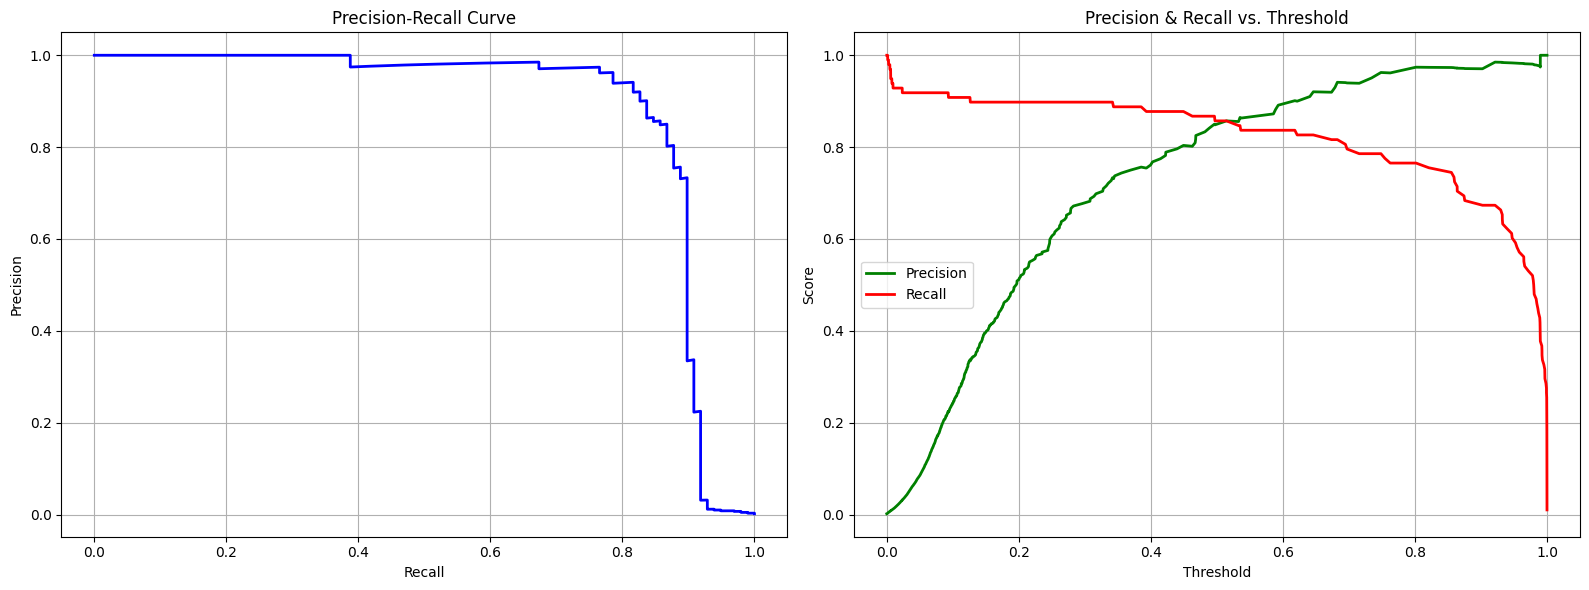

The right plot shows where Precision and Recall intersect. You can pick a threshold to prioritize one over the other.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get probability scores for the test set
y_scores = grid_search_smote.predict_proba(X_test)[:, 1]

# Calculate metrics
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Precision-Recall Curve
ax1.plot(recall, precision, color='blue', lw=2)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve')
ax1.grid(True)

# Plot 2: Precision & Recall vs Threshold
# Note: thresholds has one less element than precision/recall
ax2.plot(thresholds, precision[:-1], label='Precision', color='green', lw=2)
ax2.plot(thresholds, recall[:-1], label='Recall', color='red', lw=2)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Precision & Recall vs. Threshold')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("The right plot shows where Precision and Recall intersect. You can pick a threshold to prioritize one over the other.")

### Hybrid Strategy: Using Isolation Forest Scores as Features

In this approach, we use the `decision_function` of the Isolation Forest (which represents the anomaly score) as an additional input feature for our supervised Random Forest. This combines the strengths of unsupervised outlier detection with supervised classification.

In [ ]:
import numpy as np

# 1. Generate Anomaly Scores for the entire dataset
# Note: isolation_forest was trained on the full X earlier
iso_scores = isolation_forest.decision_function(X)

# 2. Add the scores as a new feature to our training and testing sets
X_hybrid = X.copy()
X_hybrid['Iso_Score'] = iso_scores

# 3. Re-split the data using the same random state for consistency
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hybrid, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Apply SMOTE with the optimized 0.1 ratio found earlier
smote_h = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res_h, y_train_res_h = smote_h.fit_resample(X_train_h, y_train_h)

# 5. Train the Random Forest on the hybrid dataset
rf_hybrid = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf_hybrid.fit(X_train_res_h, y_train_res_h)

# 6. Evaluate
y_pred_hybrid = rf_hybrid.predict(X_test_h)
print("Hybrid Model (RF + SMOTE + Isolation Forest Scores) Report:")
print(classification_report(y_test_h, y_pred_hybrid))

Hybrid Model (RF + SMOTE + Isolation Forest Scores) Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.86      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# Summary of Anomaly Detection Results

## 1. Dataset Overview
- **Total Transactions**: 284,807
- **Normal Transactions (Class 0)**: 284,315
- **Fraudulent Transactions (Class 1)**: 492
- **Contamination Rate**: ~0.17%

## 2. Model Performance Comparison

| Model | Strategy | Precision | Recall | F1-Score | Notes |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Isolation Forest** | Unsupervised (All Features) | 0.26 | 0.26 | 0.26 | Baseline unsupervised performance. |
| **Gaussian Prob.** | Unsupervised (Top 5 Features) | 0.43 | 0.76 | 0.55 | Significant boost from feature selection. |
| **XGBoost** | Supervised (Weighted) | 0.33 | 0.87 | 0.47 | High recall, but many false positives. |
| **Optimized RF** | Supervised + Tuning | 0.66 | 0.85 | 0.74 | RF depth and leaf tuning. |
| **RF + Tuned SMOTE** | **Sampling Strategy (0.1)** | **0.86** | **0.86** | **0.86** | **Best performing model overall.** |
| **Hybrid Model** | **RF + SMOTE + Iso-Score** | **0.84** | **0.86** | **0.85** | Confirmed RF already captured outlier patterns. |

## 3. Key Insights
- **Optimal Oversampling Ratio**: We discovered that balancing classes to 50/50 (default SMOTE) was less effective than a 10% ratio (0.1 strategy). This prevented overfitting and boosted Precision significantly.
- **Feature Engineering vs. Hybridization**: The Hybrid model showed that unsupervised anomaly scores are a strong feature, but for this specific dataset, a well-tuned Random Forest can extract that information independently from the raw features.
- **Precision-Recall Balance**: We achieved a stable balance of 86% across both metrics. Further improvements would likely require new features (like geographical data or user history) rather than algorithmic changes.
- **Final Recommendation**: Use the **Random Forest with Tuned SMOTE (0.1)**. It provides high precision and recall while remaining simpler to maintain than the hybrid approach.